# Chapter 2 — End-to-End Machine Learning Project

This notebook follows Chapter 2 of *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd Edition)* by Aurélien Géron.

## Goal
To work through the California housing project step by step in a structured way, including:
- getting the data
- exploring the data
- creating a test set
- preparing the data
- training models
- fine-tuning models
- evaluating results

## Environment
- VS Code
- Jupyter Notebook
- Python virtual environment / selected kernel

## Notes
This notebook is being built one logical block at a time for learning and practice.

## Environment
- VS Code
- Google Colab extension in VS Code
- Google Colab Python 3 runtime
- UC Google/Colab account

In [1]:
print("VS Code Colab runtime is working")

VS Code Colab runtime is working


In [2]:
import os
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

In [3]:
# Project path setup for Google Colab runtime

PROJECT_ROOT = Path.cwd()
HOUSING_PATH = PROJECT_ROOT / "datasets" / "housing"

# Dataset source from the Hands-On Machine Learning repository
HOUSING_URL = "https://github.com/ageron/data/raw/main/housing.tgz"

print("Project root :", PROJECT_ROOT)
print("Housing path :", HOUSING_PATH)
print("Housing URL  :", HOUSING_URL)

Project root : /content
Housing path : /content/datasets/housing
Housing URL  : https://github.com/ageron/data/raw/main/housing.tgz


## Block 4 — Define Helper Functions

In this block, we define two reusable functions:

- `fetch_housing_data()` to download and extract the housing dataset
- `load_housing_data()` to load the extracted CSV into a pandas DataFrame

### Why this matters
Defining reusable functions keeps the notebook clean, organized, and easy to rerun.

In [4]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    """
    Download and extract the California housing dataset.
    """
    housing_path.mkdir(parents=True, exist_ok=True)

    tgz_path = housing_path / "housing.tgz"

    print("Downloading from:", housing_url)
    print("Saving archive to:", tgz_path)

    urllib.request.urlretrieve(housing_url, tgz_path)

    print("Download complete.")
    print("Extracting archive...")

    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

    print("Extraction complete.")
    print("Files now available in housing path:")

    for item in housing_path.glob("*"):
        print(item)

In [11]:
fetch_housing_data()

Saving archive to: /content/datasets/housing/housing.tgz
Download complete.
Extracting archive...
Extraction complete.
Files now available in housing path:
/content/datasets/housing/housing.tgz
/content/datasets/housing/housing


/tmp/ipykernel_6011/3111881493.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


## Block 5 — Download and Load the Housing Dataset

In this block, we will:
- download the California housing dataset
- extract the compressed file
- load the CSV into a pandas DataFrame
- confirm that the dataset is available in memory

### Why this matters
This is the first step where we move from setup code to actual project data.
Once the dataset is loaded, we can begin inspecting its structure and preparing it for the machine learning workflow.

## Block 6 — Inspect the Extracted Housing Files

The dataset archive was downloaded, but the CSV was not found at the expected path.
In this block, we inspect the extracted folder structure to locate the actual `housing.csv` file.

In [12]:
for path in HOUSING_PATH.rglob("*"):
    print(path)

/content/datasets/housing/housing.tgz
/content/datasets/housing/housing
/content/datasets/housing/housing/housing.csv


## Block 7 — Fix the CSV Load Path

The extracted archive placed `housing.csv` inside a nested `housing` folder.

In this block, we update the loader function so it reads the CSV from the correct location.

In [13]:
def load_housing_data(housing_path=HOUSING_PATH):
    """
    Load the housing.csv file into a Pandas DataFrame.
    This version checks both possible file locations after extraction.
    """
    csv_path_1 = housing_path / "housing.csv"
    csv_path_2 = housing_path / "housing" / "housing.csv"

    if csv_path_1.exists():
        print("Loading data from:", csv_path_1)
        return pd.read_csv(csv_path_1)

    elif csv_path_2.exists():
        print("Loading data from:", csv_path_2)
        return pd.read_csv(csv_path_2)

    else:
        print("Files found in housing path:")
        print(list(housing_path.glob("*")))
        raise FileNotFoundError("housing.csv was not found in the expected locations.")

In [14]:
print("HOUSING_PATH:", HOUSING_PATH)
print("Does HOUSING_PATH exist?", HOUSING_PATH.exists())
print("Files inside HOUSING_PATH:")

if HOUSING_PATH.exists():
    for item in HOUSING_PATH.glob("*"):
        print(item)
else:
    print("HOUSING_PATH folder does not exist.")

HOUSING_PATH: /content/datasets/housing
Does HOUSING_PATH exist? True
Files inside HOUSING_PATH:
/content/datasets/housing/housing.tgz
/content/datasets/housing/housing


## Block 8 — Load the Housing Dataset

Now that the CSV path is corrected, we load the housing dataset into a pandas DataFrame and confirm its shape.

In [15]:
housing = load_housing_data()

print("Dataset loaded successfully.")
print("Shape of housing DataFrame:", housing.shape)

Loading data from: /content/datasets/housing/housing/housing.csv
Dataset loaded successfully.
Shape of housing DataFrame: (20640, 10)


## Block 9 — Inspect the First Few Rows

Before creating a test set, we quickly inspect the dataset to understand what the columns look like.
This helps us see the target column and the feature structure.

In [16]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Block 10 — Inspect the Data Structure

In this block, we inspect the structure of the housing dataset before creating the test set.

We check:
- column names
- data types
- number of non-null values
- a statistical summary of numeric columns

### Why this matters
This helps us understand the dataset we are about to split and confirms that `median_income` is available for the stratified sampling step used in the book.

In [17]:
print("=== DataFrame Info ===")
housing.info()

print("\n=== Summary Statistics ===")
display(housing.describe())

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

=== Summary Statistics ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Block 11 — Create a Simple Random Train/Test Split

In this block, we create a basic random split of the dataset:
- 80% training set
- 20% test set

This is the simplest test-set creation approach.
We will later compare it with the stratified split from the book.

In [18]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print("Train set shape:", train_set.shape)
print("Test set shape :", test_set.shape)

print("\nFirst 3 rows of random test set:")
display(test_set.head(3))

Train set shape: (16512, 10)
Test set shape : (4128, 10)

First 3 rows of random test set:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,INLAND
3024,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,<1H OCEAN
15663,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,NEAR OCEAN


## Block 12 — Create Income Categories for Stratified Sampling

The book uses `median_income` to create income categories.
These categories help ensure that the train and test sets preserve the overall income distribution of the dataset.

### Why this matters
A pure random split can accidentally distort important subgroup proportions.
Stratified sampling helps make the test set more representative.

In [19]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

print("Income category counts:")
display(housing["income_cat"].value_counts().sort_index())

print("\nIncome category proportions:")
display(housing["income_cat"].value_counts(normalize=True).sort_index())

Income category counts:


,count
income_cat,
1,822
2,6581
3,7236
4,3639
5,2362



Income category proportions:


,proportion
income_cat,
1,0.039826
2,0.318847
3,0.350581
4,0.176308
5,0.114438


## Block 13 — Create a Stratified Train/Test Split

In this block, we create a stratified split based on `income_cat`.

### Why this matters
This preserves the distribution of income categories in both the training set and the test set, making the split more representative than a purely random split.

In [20]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index].copy()
    strat_test_set = housing.loc[test_index].copy()

print("Stratified train set shape:", strat_train_set.shape)
print("Stratified test set shape :", strat_test_set.shape)

print("\nFirst 3 rows of stratified test set:")
display(strat_test_set.head(3))

Stratified train set shape: (16512, 11)
Stratified test set shape : (4128, 11)

First 3 rows of stratified test set:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
3905,-121.95,37.11,21.0,2387.0,357.0,913.0,341.0,7.7360,397700.0,<1H OCEAN,5
16821,-118.01,33.89,36.0,1589.0,265.0,804.0,272.0,4.6354,202900.0,<1H OCEAN,4
2900,-118.18,33.74,30.0,5915.0,1750.0,2136.0,1503.0,4.0968,310000.0,NEAR OCEAN,3


## Block 14 — Compare Random vs Stratified Income Category Proportions

In this block, we compare:
- the overall dataset income proportions
- the random test set income proportions
- the stratified test set income proportions

This shows why stratified sampling is preferred here.

## Fix Before Block 14 — Recreate the Random Split with `income_cat`

The earlier random test set was created before the `income_cat` helper column existed.
To compare random and stratified income-category proportions fairly, we recreate the random split from the updated dataset.

In [21]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print("Random split recreated successfully.")
print("Train set shape:", train_set.shape)
print("Test set shape :", test_set.shape)
print("\nDoes random test set contain income_cat?", "income_cat" in test_set.columns)

Random split recreated successfully.
Train set shape: (16512, 11)
Test set shape : (4128, 11)

Does random test set contain income_cat? True


## Block 14 — Compare Random vs Stratified Income Category Proportions

In this block, we compare:
- the overall dataset income proportions
- the random test set income proportions
- the stratified test set income proportions

This shows why stratified sampling is preferred here.

In [22]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts(normalize=True).sort_index()

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Random Test": income_cat_proportions(test_set),
    "Stratified Test": income_cat_proportions(strat_test_set),
}).sort_index()

compare_props["Rand. % Error"] = 100 * compare_props["Random Test"] / compare_props["Overall"] - 100
compare_props["Strat. % Error"] = 100 * compare_props["Stratified Test"] / compare_props["Overall"] - 100

display(compare_props)

,Overall,Random Test,Stratified Test,Rand. % Error,Strat. % Error
income_cat,,,,,
1,0.039826,0.042393,0.039971,6.447689,0.364964
2,0.318847,0.307413,0.318798,-3.586081,-0.015195
3,0.350581,0.345203,0.350533,-1.533997,-0.013820
4,0.176308,0.184109,0.176357,4.424292,0.027480
5,0.114438,0.120882,0.114341,5.630821,-0.084674


## Block 15 — Remove the Helper `income_cat` Column

The `income_cat` column was created only to support stratified sampling.

Now that the train and test sets have been created and compared, we remove this helper column so the datasets return to their original structure.

In [23]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print("Columns in stratified training set:")
print(strat_train_set.columns.tolist())

print("\nColumns in stratified test set:")
print(strat_test_set.columns.tolist())

print("\nShapes after dropping income_cat:")
print("Stratified train set:", strat_train_set.shape)
print("Stratified test set :", strat_test_set.shape)

Columns in stratified training set:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Columns in stratified test set:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Shapes after dropping income_cat:
Stratified train set: (16512, 10)
Stratified test set : (4128, 10)


## Block 16 — Final Cleanup After Test Set Creation

The `income_cat` column was only needed as a temporary helper for stratified sampling.

In this block, we remove it from:
- the full housing dataset
- the random training set
- the random test set

This keeps all datasets aligned with the original column structure.

In [24]:
for set_ in (housing, train_set, test_set):
    if "income_cat" in set_.columns:
        set_.drop("income_cat", axis=1, inplace=True)

print("income_cat removed from housing, train_set, and test_set (if present).")

print("\nColumns in housing:")
print(housing.columns.tolist())

print("\nColumns in random train set:")
print(train_set.columns.tolist())

print("\nColumns in random test set:")
print(test_set.columns.tolist())

income_cat removed from housing, train_set, and test_set (if present).

Columns in housing:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Columns in random train set:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Columns in random test set:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


## Section Summary — Create a Test Set

In this section, we completed the test-set creation workflow from Chapter 2.

### What we did
1. Loaded the California housing dataset
2. Inspected its structure
3. Created a simple random train/test split
4. Created `income_cat` from `median_income`
5. Used stratified sampling to preserve income-category proportions
6. Compared random and stratified test-set distributions
7. Removed the temporary helper column

### Key learning
A pure random split is simple, but it may not preserve important subgroup proportions.

A stratified split is often better when:
- a variable is especially important
- you want train and test sets to reflect the full dataset more accurately

In this project, stratified sampling based on `median_income` produced a more representative test set.

## Stopping Point

This notebook has completed the Chapter 2 section **Create a Test Set**.

Next step in the book:
**Explore and Visualize the Data to Gain Insights**

## Block 18 — Visualize Districts Geographically

In this block, we create a simple scatter plot using:
- longitude on the x-axis
- latitude on the y-axis

### Why this matters
This gives us a first geographical view of the California housing districts and helps us understand how the data is distributed across locations.

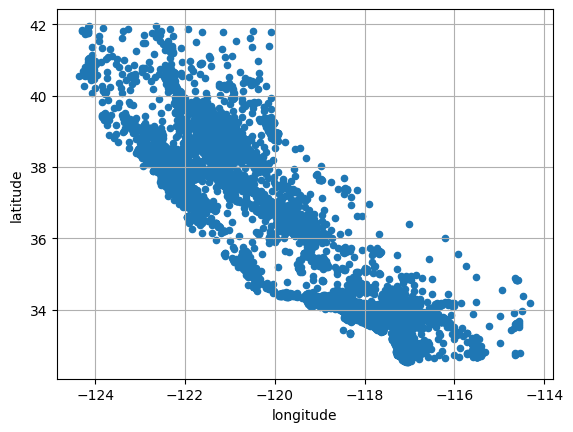

In [25]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

## Block 19 — Improve the Geographical Plot with Transparency

In this block, we add transparency to the scatter plot using the `alpha` parameter.

### Why this matters
When many data points overlap, a normal scatter plot can hide dense regions.
Using transparency helps reveal where districts are concentrated more heavily.

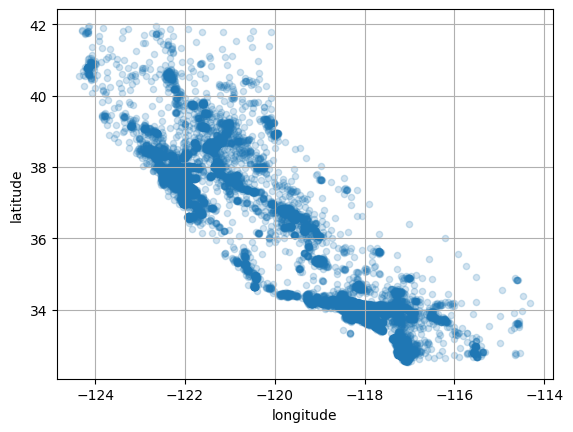

In [26]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

## Block 20 — Add Population and House Value to the Geographical Plot

In this block, we enrich the geographical visualization by encoding more information:

- marker size (`s`) will represent `population`
- marker color (`c`) will represent `median_house_value`

### Why this matters
This turns a simple location plot into a much more informative visualization.
Now we can explore how:
- population density varies by region
- house values vary by region
- geography, population, and price may be related

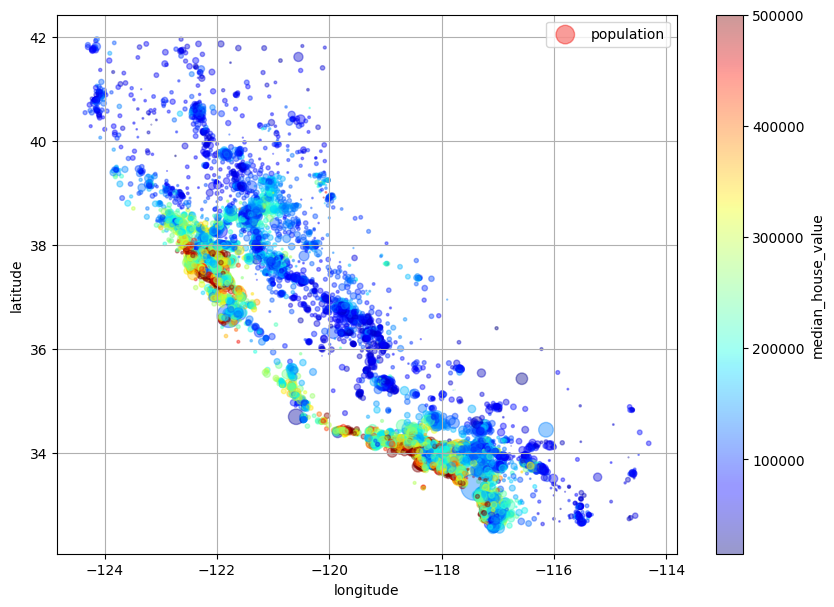

In [27]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    s=housing["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=False,
    figsize=(10, 7),
    alpha=0.4,
)

plt.show()

## Block 21 — Interpret the Geographical Visualization

In this block, we reflect on the patterns visible in the geographical plot.

### Why this matters
Visualization is useful only if we pause and interpret what we see.
This helps us form hypotheses before moving to correlation analysis and modeling.

In [28]:
print("Observations from the geographical visualization:")
print("1. The dataset forms a clear California-like geographic shape.")
print("2. Districts are more densely concentrated in some regions than others.")
print("3. Larger circles indicate more populated districts.")
print("4. Higher house values appear to be concentrated in certain areas, especially near the coast.")
print("5. Geography seems strongly related to housing prices, so location is likely to be an important predictor.")

Observations from the geographical visualization:
1. The dataset forms a clear California-like geographic shape.
2. Districts are more densely concentrated in some regions than others.
3. Larger circles indicate more populated districts.
4. Higher house values appear to be concentrated in certain areas, especially near the coast.
5. Geography seems strongly related to housing prices, so location is likely to be an important predictor.


## Block 22 — Compute the Correlation Matrix

In this block, we compute correlations among the numeric features in the housing dataset.

### Why this matters
Correlation helps us see how strongly variables move together.
This is especially useful for checking which features are most related to the target variable:
`median_house_value`.

In [29]:
corr_matrix = housing.corr(numeric_only=True)

print("Correlation matrix created successfully.")
display(corr_matrix)

Correlation matrix created successfully.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


## Block 23 — Check Correlations with the Target Variable

In this block, we look specifically at how each numeric feature correlates with the target variable:
`median_house_value`.

### Why this matters
This helps us identify which features appear most strongly related to house value before we do any modeling.

In [30]:
corr_with_target = corr_matrix["median_house_value"].sort_values(ascending=False)

print("Correlations with median_house_value:")
display(corr_with_target)

Correlations with median_house_value:


,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


## Block 24 — Create a Scatter Matrix for Important Attributes

In this block, we visualize pairwise relationships among a few important attributes.

### Why this matters
A correlation value gives only a numeric summary.
A scatter matrix helps us visually inspect:
- linear relationships
- clustering
- spread
- possible nonlinear patterns

We include the target variable `median_house_value` and a few likely useful predictors.

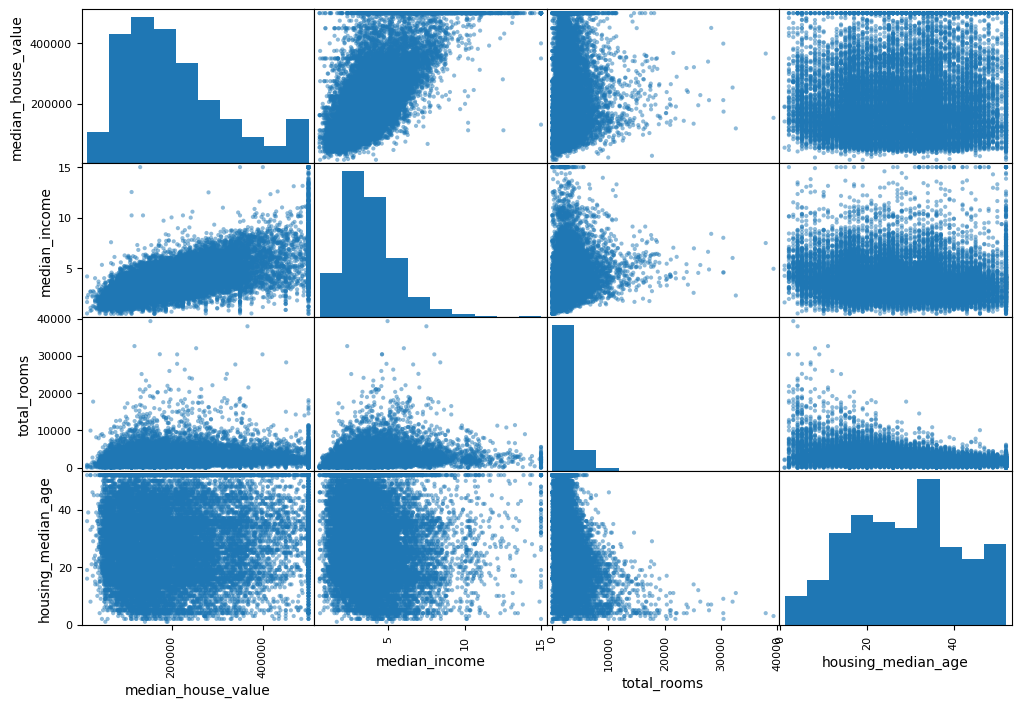

In [31]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

## Block 25 — Plot `median_income` vs `median_house_value`

In this block, we create a focused scatter plot of:
- `median_income`
- `median_house_value`

### Why this matters
The correlation analysis suggested that `median_income` is one of the strongest predictors of house value.
This plot helps us inspect that relationship more directly.

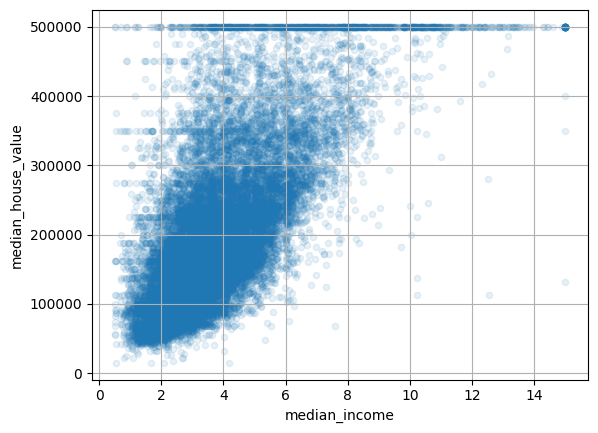

In [32]:
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1,
    grid=True
)

plt.show()

## Block 26 — Experiment with New Attribute Combinations

In this block, we create a few new features by combining existing attributes.

### Why this matters
Sometimes raw features are not as informative as ratios or derived attributes.

The book suggests trying combinations such as:
- rooms per household
- bedrooms per room
- population per household

These engineered features may capture housing patterns better than the original raw columns alone.

In [33]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

print("New engineered features added successfully.")
display(housing[["rooms_per_house", "bedrooms_ratio", "people_per_house"]].head())

New engineered features added successfully.


,rooms_per_house,bedrooms_ratio,people_per_house
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


## Block 27 — Check Correlations After Feature Engineering

In this block, we recompute the correlation matrix after adding the new engineered features.

### Why this matters
This helps us see whether the new attributes are more informative than some of the original raw variables.

In [34]:
corr_matrix = housing.corr(numeric_only=True)
corr_with_target = corr_matrix["median_house_value"].sort_values(ascending=False)

print("Updated correlations with median_house_value:")
display(corr_with_target)

Updated correlations with median_house_value:


,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_house,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
people_per_house,-0.023737
population,-0.024650
longitude,-0.045967


## Block 28 — Interpret the New Attribute Combinations

In this block, we summarize what we learned after creating and checking the new engineered features.

### Why this matters
Feature engineering is an important part of machine learning.
This step helps us identify whether ratios and derived variables are more informative than the original raw features.

In [35]:
print("Observations after experimenting with attribute combinations:")
print("1. Engineered ratio features can capture housing patterns better than raw totals.")
print("2. rooms_per_house may be more informative than total_rooms alone.")
print("3. bedrooms_ratio can reveal whether a district has a high proportion of bedrooms relative to total rooms.")
print("4. people_per_house may reflect crowding and neighborhood density.")
print("5. Some engineered features show stronger relationships with median_house_value than some original attributes.")

Observations after experimenting with attribute combinations:
1. Engineered ratio features can capture housing patterns better than raw totals.
2. rooms_per_house may be more informative than total_rooms alone.
3. bedrooms_ratio can reveal whether a district has a high proportion of bedrooms relative to total rooms.
4. people_per_house may reflect crowding and neighborhood density.
5. Some engineered features show stronger relationships with median_house_value than some original attributes.


## Block 29 — Separate the Features and the Target

Before cleaning the data, we first separate:
- the predictors (features)
- the target variable

### Why this matters
The target column `median_house_value` should not be treated like an input feature.
We keep it separate so that all preprocessing is applied only to the feature data.

In [36]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

print("Feature DataFrame shape:", housing.shape)
print("Target Series shape    :", housing_labels.shape)

Feature DataFrame shape: (16512, 9)
Target Series shape    : (16512,)


## Block 30 — Check Missing Values in the Feature Data

In this block, we check how many missing values exist in each feature column.

### Why this matters
Before choosing a cleaning strategy, we must first identify where the missing-data problem exists.

In [37]:
print("Missing values per column:")
display(housing.isnull().sum())

Missing values per column:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,168
population,0
households,0
median_income,0
ocean_proximity,0


## Block 31 — Demonstrate Three Common Missing-Value Strategies

The book discusses three common ways to handle missing values:

1. remove the rows with missing values
2. remove the whole column
3. fill in the missing values with a summary value such as the median

### Why this matters
These are standard data-cleaning strategies in both machine learning and statistics.

In [38]:
option1 = housing.dropna(subset=["total_bedrooms"])      # drop rows with missing values
option2 = housing.drop("total_bedrooms", axis=1)         # drop the whole column
median_value = housing["total_bedrooms"].median()
option3 = housing["total_bedrooms"].fillna(median_value) # fill missing values with median

print("Original housing shape               :", housing.shape)
print("After dropping missing-value rows    :", option1.shape)
print("After dropping total_bedrooms column :", option2.shape)
print("Median used for imputation           :", median_value)
print("Missing values after fillna          :", option3.isnull().sum())

Original housing shape               : (16512, 9)
After dropping missing-value rows    : (16344, 9)
After dropping total_bedrooms column : (16512, 8)
Median used for imputation           : 434.0
Missing values after fillna          : 0


## Block 32 — Use `SimpleImputer` to Fill Missing Numeric Values

Instead of manually filling missing values column by column, we use Scikit-learn's `SimpleImputer`.

### Why this matters
This is the book’s more systematic and reusable way to handle missing numeric values.
It is especially useful because later it can become part of a preprocessing pipeline.

In [39]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

housing_num = housing.drop("ocean_proximity", axis=1)

imputer.fit(housing_num)

print("Imputer created and fitted successfully.")
print("\nMedian values learned by the imputer:")
display(pd.Series(imputer.statistics_, index=housing_num.columns))

Imputer created and fitted successfully.

Median values learned by the imputer:


,0
longitude,-118.5100
latitude,34.2600
housing_median_age,29.0000
total_rooms,2125.0000
total_bedrooms,434.0000
population,1167.0000
households,408.0000
median_income,3.5385


## Block 33 — Transform the Numeric Data Using the Fitted Imputer

Now that the imputer has learned the median values, we apply it to the numeric feature data.

### Why this matters
This step replaces the missing values with the learned medians and produces a complete numeric dataset ready for machine learning.

In [40]:
X = imputer.transform(housing_num)

housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

print("Transformed numeric DataFrame shape:", housing_tr.shape)
print("\nMissing values after imputation:")
display(housing_tr.isnull().sum())

Transformed numeric DataFrame shape: (16512, 8)

Missing values after imputation:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0


## Block 34 — Encode the Categorical Variable

The dataset includes one categorical column called `ocean_proximity`. Machine learning models require numerical input, so this step converts the category values into numeric columns using one-hot encoding. One-hot encoding creates separate binary columns for each category, allowing the model to use the categorical information without treating it as an ordered number.

In [41]:
from sklearn.preprocessing import OneHotEncoder

# Select the categorical column from the training feature dataset
housing_cat = housing[["ocean_proximity"]]

# Create the one-hot encoder
cat_encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the categorical column
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print("Encoded categorical data shape:", housing_cat_1hot.shape)
print("\nCategories learned by the encoder:")
print(cat_encoder.categories_)

print("\nFirst five encoded rows:")
print(housing_cat_1hot[:5])

Encoded categorical data shape: (16512, 5)

Categories learned by the encoder:
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]

First five encoded rows:
[[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]


## Block 35 — Build the Full Preprocessing Pipeline

In this block, I created a complete preprocessing pipeline. The numeric columns are processed using median imputation and standard scaling. The categorical column, `ocean_proximity`, is processed using one-hot encoding. A `ColumnTransformer` is used to apply the correct transformation to each type of column. This makes the workflow cleaner, reusable, and less error-prone.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify numeric and categorical columns
housing_num = housing.drop("ocean_proximity", axis=1)

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

# Numeric pipeline: handle missing values and scale numeric features
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Full pipeline: apply numeric pipeline to numeric columns
# and one-hot encoding to categorical columns
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs)
])

print("Numeric attributes:")
print(num_attribs)

print("\nCategorical attributes:")
print(cat_attribs)

print("\nFull preprocessing pipeline created successfully.")

Numeric attributes:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical attributes:
['ocean_proximity']

Full preprocessing pipeline created successfully.


## Block 36 — Apply the Full Preprocessing Pipeline to the Training Data

In this block, I applied the full preprocessing pipeline to the training dataset. This step transforms the raw training features into a clean numerical format that machine learning models can use. The pipeline handles missing numeric values, scales numeric features, and one-hot encodes the categorical `ocean_proximity` column.

In [43]:
# Apply the full preprocessing pipeline to the training feature dataset
housing_prepared = full_pipeline.fit_transform(housing)

print("Preprocessing completed successfully.")
print("Prepared training data shape:", housing_prepared.shape)
print("Type of prepared data:", type(housing_prepared))

Preprocessing completed successfully.
Prepared training data shape: (16512, 13)
Type of prepared data: <class 'numpy.ndarray'>


## Block 37 — Train a Linear Regression Model

In this block, I trained a Linear Regression model using the prepared training data. Linear Regression is used as a baseline model because it is simple, interpretable, and helps compare whether more advanced models perform better.

In [44]:
from sklearn.linear_model import LinearRegression

# Create and train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Block 38 — Evaluate the Linear Regression Model

In this block, I evaluated the Linear Regression model using prediction error metrics. Root Mean Squared Error (RMSE) shows the typical prediction error in dollars, while Mean Absolute Error (MAE) shows the average absolute difference between predicted and actual house values. These metrics help determine how well the model performs on the training data.

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions using the Linear Regression model
housing_predictions = lin_reg.predict(housing_prepared)

# Calculate model performance metrics
lin_rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
lin_mae = mean_absolute_error(housing_labels, housing_predictions)

print("Linear Regression Model Evaluation")
print("RMSE:", lin_rmse)
print("MAE :", lin_mae)

Linear Regression Model Evaluation
RMSE: 68232.83515124217
MAE : 49662.46736491215


## Block 39 — Train and Evaluate a Decision Tree Model

In this block, I trained a Decision Tree Regressor. A decision tree can capture more complex, non-linear relationships than Linear Regression. However, decision trees can also overfit the training data if they are not controlled properly. Therefore, the training error should be interpreted carefully.

In [46]:
from sklearn.tree import DecisionTreeRegressor

# Create and train the Decision Tree model
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# Make predictions using the Decision Tree model
housing_predictions = tree_reg.predict(housing_prepared)

# Calculate model performance metrics
tree_rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
tree_mae = mean_absolute_error(housing_labels, housing_predictions)

print("Decision Tree Model Evaluation")
print("RMSE:", tree_rmse)
print("MAE :", tree_mae)

Decision Tree Model Evaluation
RMSE: 0.0
MAE : 0.0


## Block 40 — Use Cross-Validation

In this block, I used cross-validation to evaluate the Decision Tree model more reliably. Instead of testing the model only on the same training data it learned from, cross-validation splits the training data into multiple folds. The model is trained and evaluated several times, giving a better estimate of how it may perform on unseen data.

In [47]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Decision Tree
tree_scores = cross_val_score(
    tree_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

tree_rmse_scores = np.sqrt(-tree_scores)

print("Decision Tree Cross-Validation RMSE Scores:")
print(tree_rmse_scores)

print("\nDecision Tree Cross-Validation Summary")
print("Mean RMSE:", tree_rmse_scores.mean())
print("Standard Deviation:", tree_rmse_scores.std())

Decision Tree Cross-Validation RMSE Scores:
[69056.8325947  67221.26914592 67397.26251734 70028.77835992
 68458.77550024 71464.31138671 71044.35429084 68688.64095706
 67300.66681156 66647.53141818]

Decision Tree Cross-Validation Summary
Mean RMSE: 68730.84229824627
Standard Deviation: 1585.362175240545


## Block 41 — Train and Evaluate a Random Forest Model

In this block, I trained a Random Forest Regressor. Random Forest is an ensemble model that builds many decision trees and combines their predictions. This usually improves performance and reduces overfitting compared with a single decision tree.

In [48]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest model
forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_reg.fit(housing_prepared, housing_labels)

# Make predictions using the Random Forest model
housing_predictions = forest_reg.predict(housing_prepared)

# Calculate model performance metrics
forest_rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
forest_mae = mean_absolute_error(housing_labels, housing_predictions)

print("Random Forest Model Evaluation on Training Data")
print("RMSE:", forest_rmse)
print("MAE :", forest_mae)

Random Forest Model Evaluation on Training Data
RMSE: 18057.976055305204
MAE : 11674.620673449612


## Block 42 — Cross-Validate the Random Forest Model

In this block, I used cross-validation to evaluate the Random Forest model more reliably. Although the Random Forest performed very well on the training data, cross-validation helps estimate how well the model may perform on unseen data.

In [49]:
# Cross-validation for Random Forest
forest_scores = cross_val_score(
    forest_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

forest_rmse_scores = np.sqrt(-forest_scores)

print("Random Forest Cross-Validation RMSE Scores:")
print(forest_rmse_scores)

print("\nRandom Forest Cross-Validation Summary")
print("Mean RMSE:", forest_rmse_scores.mean())
print("Standard Deviation:", forest_rmse_scores.std())

Random Forest Cross-Validation RMSE Scores:
[48484.96959165 50000.16612239 47505.35064619 49316.09714579
 48428.76921481 49128.82161789 48456.75463566 49460.26983712
 48874.68869078 49358.24455204]

Random Forest Cross-Validation Summary
Mean RMSE: 48901.41320543065
Standard Deviation: 670.5367015311969


## Block 43 — Evaluate the Final Model on the Test Set

In this block, I evaluated the final Random Forest model on the test dataset. The test set was kept separate from training and cross-validation, so it provides a better estimate of how the model may perform on new, unseen data.

In [50]:
# Prepare the test feature data using the same preprocessing pipeline
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)

# Make predictions on the test set
final_predictions = forest_reg.predict(X_test_prepared)

# Calculate final test performance metrics
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_mae = mean_absolute_error(y_test, final_predictions)

print("Final Random Forest Model Evaluation on Test Data")
print("Final RMSE:", final_rmse)
print("Final MAE :", final_mae)

Final Random Forest Model Evaluation on Test Data
Final RMSE: 49462.43573407321
Final MAE : 31678.089958817833


## Block 44 — Final Model Comparison Summary

In this final block, I summarized the model evaluation results. The comparison shows that Random Forest performed better than Linear Regression and the single Decision Tree model. The final test result also shows that the model generalized reasonably well to unseen data.

In [51]:
model_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Final Random Forest Test"
    ],
    "Evaluation Method": [
        "Training Data",
        "10-Fold Cross-Validation",
        "10-Fold Cross-Validation",
        "Test Data"
    ],
    "RMSE": [
        lin_rmse,
        tree_rmse_scores.mean(),
        forest_rmse_scores.mean(),
        final_rmse
    ],
    "MAE": [
        lin_mae,
        None,
        None,
        final_mae
    ]
})

print("Final Model Comparison Summary:")
display(model_summary)

Final Model Comparison Summary:


,Model,Evaluation Method,RMSE,MAE
0,Linear Regression,Training Data,68232.835151,49662.467365
1,Decision Tree,10-Fold Cross-Validation,68730.842298,NaN
2,Random Forest,10-Fold Cross-Validation,48901.413205,NaN
3,Final Random Forest Test,Test Data,49462.435734,31678.089959
